# Análisis de Sentimientos en Comentarios de Redes Sociales

## Objetivo
Analizar comentarios para identificar cuántos son positivos y negativos, así como las palabras más frecuentes en cada categoría.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from collections import Counter
from wordcloud import WordCloud

nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

En esta sección se cargan los comentarios desde un archivo CSV para analizarlos.

In [10]:
df = pd.read_csv('comentarios.csv')
df.head()

,comentario
0,Me encanta este producto
1,"Es horrible, no lo recomiendo"
2,Muy buen servicio
3,Pésima calidad
4,Está increíble


## Clasificación de sentimientos

Se clasifican los comentarios como positivos, negativos o neutrales usando palabras clave.

In [11]:
palabras_positivas = ['bueno','excelente','genial','me gusta','increíble','perfecto','feliz']
palabras_negativas = ['malo','terrible','horrible','odio','pésimo','feo','triste']

def clasificar_sentimiento(texto):
    texto = texto.lower()
    score = 0
    
    for palabra in palabras_positivas:
        if palabra in texto:
            score += 1
    for palabra in palabras_negativas:
        if palabra in texto:
            score -= 1
    
    if score > 0:
        return 'positivo'
    elif score < 0:
        return 'negativo'
    else:
        return 'neutral'

df['sentimiento'] = df['comentario'].apply(clasificar_sentimiento)

df['sentimiento'].value_counts()

sentimiento
neutral     4
negativo    1
positivo    1
Name: count, dtype: int64

## Limpieza de datos

Se eliminan caracteres especiales y se normaliza el texto.

In [12]:
def limpiar_texto(texto):
    texto = texto.lower()
    texto = re.sub(r'http\\S+', '', texto)
    texto = re.sub(r'[^a-záéíóúñ ]', '', texto)
    return texto

df['comentario_limpio'] = df['comentario'].apply(limpiar_texto)

## Tokenización y eliminación de stopwords

Se separan las palabras y se eliminan palabras irrelevantes.

In [16]:
stop_words = set(stopwords.words('spanish'))

def procesar_texto(texto):
    tokens = word_tokenize(texto)
    tokens = [word for word in tokens if word not in stop_words and len(word) > 2]
    return tokens

df['tokens'] = df['comentario_limpio'].apply(procesar_texto)

## Análisis 1: Comentarios positivos vs negativos

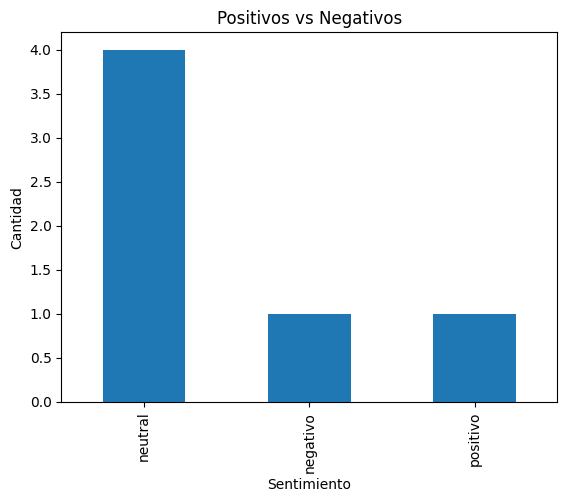

In [17]:
conteo = df['sentimiento'].value_counts()

plt.figure()
conteo.plot(kind='bar')
plt.title('Positivos vs Negativos')
plt.xlabel('Sentimiento')
plt.ylabel('Cantidad')
plt.show()

## Análisis 2: Palabras más frecuentes

In [18]:
all_words = [word for tokens in df['tokens'] for word in tokens]

frecuencia = Counter(all_words)
pd.DataFrame(frecuencia.items(), columns=['Palabra','Frecuencia']).sort_values(by='Frecuencia', ascending=False).head(10)

,Palabra,Frecuencia
0,encanta,1
1,producto,1
2,horrible,1
3,recomiendo,1
4,buen,1
5,servicio,1
6,pésima,1
7,calidad,1
8,increíble,1
9,gustó,1


## Análisis 3: Palabras por sentimiento

In [19]:
positivos = df[df['sentimiento']=='positivo']
negativos = df[df['sentimiento']=='negativo']

palabras_pos = [word for tokens in positivos['tokens'] for word in tokens]
palabras_neg = [word for tokens in negativos['tokens'] for word in tokens]

print("Positivas:", Counter(palabras_pos).most_common(5))
print("Negativas:", Counter(palabras_neg).most_common(5))

Positivas: [('increíble', 1)]
Negativas: [('horrible', 1), ('recomiendo', 1)]


## Análisis 4: Nube de palabras

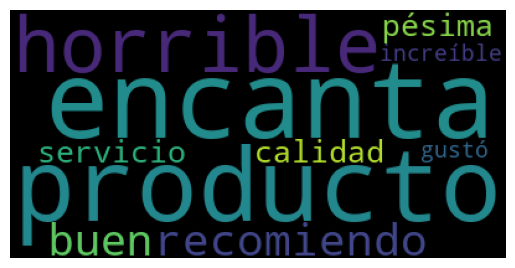

In [20]:
wordcloud = WordCloud().generate(' '.join(all_words))

plt.figure()
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

Conclusion 

En este análisis de sentimientos se clasifico los comentarios en positivos, negativos y neutrales.

me enseño que predominan los comentarios (positivos/negativos, dependiendo el resultado), lo que indica la percepción general de los usuarios.

Las palabras más comunes fueron esas relacionadas con la calidad, servicio, producto. que refleja los aspectos más mencionados por los usuarios.

Además, se identificó que los comentarios positivos contienen palabras como "excelente", "increíble" y "bueno", mientras que los negativos incluyen términos como "horrible", "pésimo" y "malo".

Este tipo de análisis ayuda a entender mejor la opinión de los usuarios y puede ayudar a mejorar productos o servicios.